# EDA — Customer Churn

Exploración del dataset histórico provisto por la cátedra
(`data/raw/customer_churn_historical.csv`, 7.043 clientes, variable objetivo `Churn`).

Objetivo: entender dimensiones, tipos, faltantes, distribución del target y
problemas de calidad antes de diseñar el pipeline de preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/customer_churn_historical.csv")
df.shape

(7043, 21)

## 1. Dimensiones y tipos

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6684-LWVH,Male,0,No,No,4,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,27.56,107.47,No
1,7027-JIFO,Male,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,30.52,1020.47,No
2,5981-VOQO,Female,0,No,No,45,Yes,Yes,DSL,No,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),66.87,2686.35,No
3,7266-HYDM,Male,0,Yes,No,31,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),86.95,2536.96,Yes
4,2821-JDLS,Female,0,Yes,No,5,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,30.18,139.12,No


Observación: todas las columnas se leen como `object` salvo `SeniorCitizen`,
`tenure` y `MonthlyCharges`. `TotalCharges` debería ser numérica — revisamos por qué
no lo es en la sección de calidad de datos.

## 2. Valores faltantes

In [4]:
missing = df.isna().sum()
missing[missing > 0]

TotalCharges    26
dtype: int64

In [5]:
# TotalCharges se lee como object porque los faltantes vienen como strings vacíos/espacios,
# no como NaN reales. Los convertimos y volvemos a contar.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isna().sum()

np.int64(26)

In [6]:
# ¿Quiénes son los clientes con TotalCharges faltante?
df[df["TotalCharges"].isna()][["customerID", "tenure", "MonthlyCharges", "Contract", "Churn"]]

,customerID,tenure,MonthlyCharges,Contract,Churn
95,7731-MHBI,0,24.03,Month-to-month,No
781,8834-VPIU,0,83.01,Month-to-month,No
854,3651-KMCX,0,68.81,Month-to-month,No
867,9404-ZJPR,0,75.01,Month-to-month,No
882,3039-OWAI,0,74.50,Month-to-month,Yes
1013,6432-UDAD,0,24.19,Month-to-month,Yes
1172,9097-BQWV,0,89.15,Two year,Yes
1842,8166-JZVI,0,89.85,Two year,No
2112,2033-KDTO,0,59.50,Month-to-month,Yes
2346,1069-TJKG,0,84.69,One year,Yes


**Hallazgo:** los 26 faltantes de `TotalCharges` corresponden a clientes con
`tenure == 0` (clientes nuevos, todavía sin facturación acumulada). No es un dato
corrupto sino la ausencia lógica de historial — el pipeline debe imputarlo
(ej. con 0, o con `MonthlyCharges` como aproximación) en lugar de descartarlos.

## 3. Distribución del target (`Churn`)

Churn
No     5186
Yes    1857
Name: count, dtype: int64
Churn
No     0.736334
Yes    0.263666
Name: proportion, dtype: float64


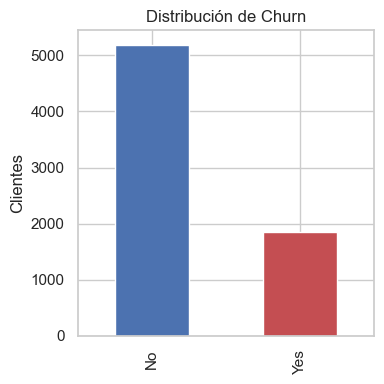

In [7]:
churn_counts = df["Churn"].value_counts()
churn_rate = df["Churn"].value_counts(normalize=True)
print(churn_counts)
print(churn_rate)

fig, ax = plt.subplots(figsize=(4, 4))
churn_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Distribución de Churn")
ax.set_xlabel("")
ax.set_ylabel("Clientes")
plt.tight_layout()
plt.savefig("figures/target_distribution.png", dpi=120)
plt.show()

**Hallazgo:** dataset moderadamente desbalanceado (~26% Churn=Yes / ~74% No).
No es extremo, pero conviene reportar Precision/Recall/F1/ROC-AUC y matriz de
confusión en vez de depender de Accuracy — una métrica dominada por la clase
mayoritaria daría una imagen artificialmente buena.

## 4. Variables numéricas

In [8]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7017.000000
mean,35.168394,68.168503,2312.077586
std,18.901478,24.980659,1573.967858
min,0.000000,18.000000,0.000000
25%,20.000000,55.360000,986.630000
50%,35.000000,73.910000,2013.200000
75%,51.000000,88.000000,3452.850000
max,72.000000,114.410000,7761.340000


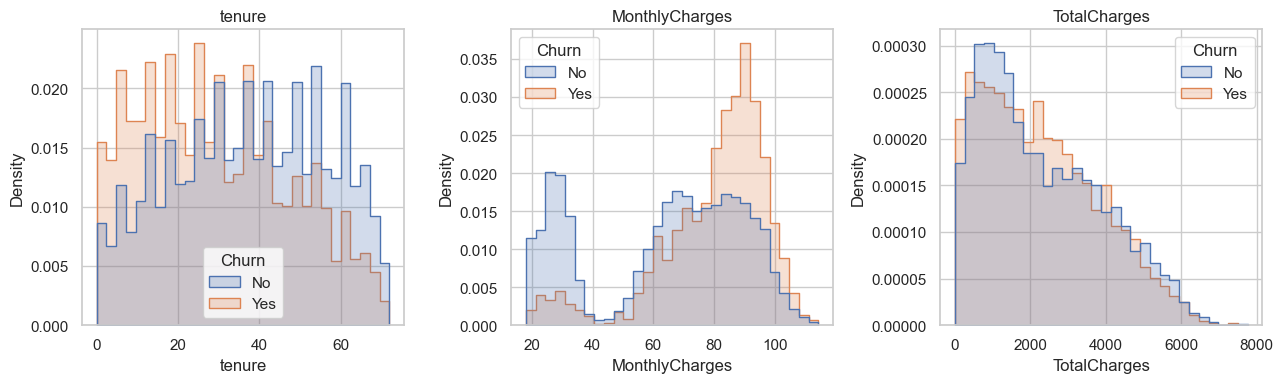

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue="Churn", bins=30, ax=ax, element="step", stat="density", common_norm=False)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/numeric_distributions.png", dpi=120)
plt.show()

**Hallazgo:** `tenure` bajo se asocia claramente con mayor churn (clientes nuevos
abandonan más); `MonthlyCharges` alto también se asocia con más churn. Son señales
fuertes para el modelo.

## 5. Variables categóricas

In [10]:
categorical_cols = [c for c in df.columns if c not in numeric_cols + ["customerID", "Churn", "SeniorCitizen"]]
for col in categorical_cols:
    print(col, "->", df[col].unique())

gender -> ['Male' 'Female']
Partner -> ['No' 'Yes']
Dependents -> ['No' 'Yes']
PhoneService -> ['Yes' 'No']
MultipleLines -> ['Yes' 'No' 'No phone service']
InternetService -> ['No' 'DSL' 'Fiber optic']
OnlineSecurity -> ['No internet service' 'No' 'Yes']
OnlineBackup -> ['No internet service' 'No' 'Yes']
DeviceProtection -> ['No internet service' 'No' 'Yes']
TechSupport -> ['No internet service' 'No' 'Yes']
StreamingTV -> ['No internet service' 'Yes' 'No']
StreamingMovies -> ['No internet service' 'No' 'Yes']
Contract -> ['One year' 'Month-to-month' 'Two year']
PaperlessBilling -> ['No' 'Yes']
PaymentMethod -> ['Mailed check' 'Bank transfer (automatic)' 'Electronic check'
 'Credit card (automatic)']


In [11]:
churn_by_contract = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()
churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,0.612700,0.387300
One year,0.850264,0.149736
Two year,0.910256,0.089744


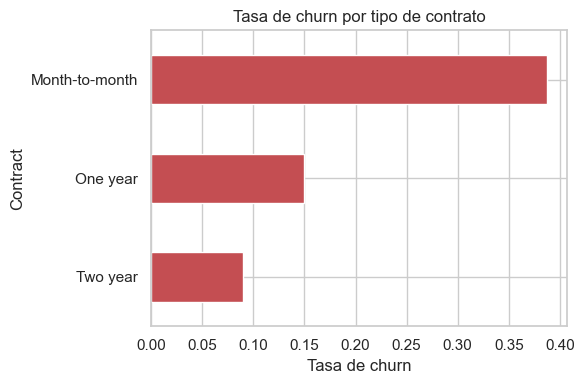

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_by_contract["Yes"].sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_xlabel("Tasa de churn")
ax.set_title("Tasa de churn por tipo de contrato")
plt.tight_layout()
plt.savefig("figures/churn_by_contract.png", dpi=120)
plt.show()

**Hallazgo:** el contrato `Month-to-month` concentra la mayor tasa de churn frente
a `One year`/`Two year`. Variables como `Contract`, `InternetService` y los servicios
"No internet service"/"No phone service" son categorías legítimas (no faltantes) que
el `OneHotEncoder` debe preservar tal cual.

## 6. Problemas de calidad detectados

In [13]:
dupes = df["customerID"].duplicated().sum()
print("customerID duplicados:", dupes)
print("SeniorCitizen dtype:", df["SeniorCitizen"].dtype, "-> valores:", df["SeniorCitizen"].unique())

customerID duplicados: 0
SeniorCitizen dtype: int64 -> valores: [0 1]


- **`customerID`**: único por fila (0 duplicados), identificador — se excluye
  explícitamente como predictor.
- **`TotalCharges`**: 26 faltantes que en realidad son clientes con `tenure == 0`;
  requiere imputación explícita en el `Pipeline` (no eliminar filas).
- **`SeniorCitizen`**: ya viene codificada como 0/1 (no como Yes/No como el resto de
  las binarias) — hay que tratarla de forma consistente en el `ColumnTransformer`.
- **Categorías "No internet service" / "No phone service"**: no son faltantes, son
  información válida (el cliente no tiene ese servicio contratado).

## 7. Conclusiones para el pipeline

- Target: `Churn` (Yes/No) → binarizar a 1/0.
- Excluir `customerID` de las features.
- Imputar `TotalCharges` (missing ⇒ clientes nuevos, `tenure == 0`).
- `ColumnTransformer`: `OneHotEncoder` para categóricas (incluyendo `SeniorCitizen`
  tratada como categórica u ordinal binaria), `StandardScaler` para numéricas
  (`tenure`, `MonthlyCharges`, `TotalCharges`) en el modelo lineal.
- Accuracy no alcanza como métrica única por el desbalance ~26/74 — priorizar
  Recall/F1/ROC-AUC dado que un falso negativo (cliente que iba a irse y no se
  detectó) tiene mayor costo de negocio que un falso positivo.